In [1]:
import torch

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [4]:
import torch.utils.data as DataLoader
from torchvision import datasets, transforms
import os

data_dir = os.path.join(path, "chest_xray")
train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")
val_dir = os.path.join(data_dir, "val")

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)

# Create data loaders
train_loader = DataLoader.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader.DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader.DataLoader(test_dataset, batch_size=32, shuffle=False)


CNN

In [5]:
import torch
import torch.nn as nn

class CNN_50(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN_50, self).__init__()
        
        # Initial conv layer (1 layer)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Layer 1: 3 bottleneck blocks (9 conv layers)
        # Block 1
        self.conv2_1a = nn.Conv2d(64, 64, kernel_size=1, stride=1, bias=False)
        self.bn2_1a = nn.BatchNorm2d(64)
        self.conv2_1b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_1b = nn.BatchNorm2d(64)
        self.conv2_1c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
        self.bn2_1c = nn.BatchNorm2d(256)
        self.conv2_1_expand = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
        self.bn2_1_expand = nn.BatchNorm2d(256)
        
        # Block 2
        self.conv2_2a = nn.Conv2d(256, 64, kernel_size=1, stride=1, bias=False)
        self.bn2_2a = nn.BatchNorm2d(64)
        self.conv2_2b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_2b = nn.BatchNorm2d(64)
        self.conv2_2c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
        self.bn2_2c = nn.BatchNorm2d(256)
        
        # Block 3
        self.conv2_3a = nn.Conv2d(256, 64, kernel_size=1, stride=1, bias=False)
        self.bn2_3a = nn.BatchNorm2d(64)
        self.conv2_3b = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_3b = nn.BatchNorm2d(64)
        self.conv2_3c = nn.Conv2d(64, 256, kernel_size=1, stride=1, bias=False)
        self.bn2_3c = nn.BatchNorm2d(256)
        
        # Layer 2: 4 bottleneck blocks (12 conv layers)
        # Block 1 (with stride=2)
        self.conv3_1a = nn.Conv2d(256, 128, kernel_size=1, stride=1, bias=False)
        self.bn3_1a = nn.BatchNorm2d(128)
        self.conv3_1b = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn3_1b = nn.BatchNorm2d(128)
        self.conv3_1c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
        self.bn3_1c = nn.BatchNorm2d(512)
        self.conv3_1_down = nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False)
        self.bn3_1_down = nn.BatchNorm2d(512)
        
        # Block 2
        self.conv3_2a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
        self.bn3_2a = nn.BatchNorm2d(128)
        self.conv3_2b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3_2b = nn.BatchNorm2d(128)
        self.conv3_2c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
        self.bn3_2c = nn.BatchNorm2d(512)
        
        # Block 3
        self.conv3_3a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
        self.bn3_3a = nn.BatchNorm2d(128)
        self.conv3_3b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3_3b = nn.BatchNorm2d(128)
        self.conv3_3c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
        self.bn3_3c = nn.BatchNorm2d(512)
        
        # Block 4
        self.conv3_4a = nn.Conv2d(512, 128, kernel_size=1, stride=1, bias=False)
        self.bn3_4a = nn.BatchNorm2d(128)
        self.conv3_4b = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3_4b = nn.BatchNorm2d(128)
        self.conv3_4c = nn.Conv2d(128, 512, kernel_size=1, stride=1, bias=False)
        self.bn3_4c = nn.BatchNorm2d(512)
        
        # Layer 3: 6 bottleneck blocks (18 conv layers)
        # Block 1 (with stride=2)
        self.conv4_1a = nn.Conv2d(512, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_1a = nn.BatchNorm2d(256)
        self.conv4_1b = nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn4_1b = nn.BatchNorm2d(256)
        self.conv4_1c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_1c = nn.BatchNorm2d(1024)
        self.conv4_1_down = nn.Conv2d(512, 1024, kernel_size=1, stride=2, bias=False)
        self.bn4_1_down = nn.BatchNorm2d(1024)
        
        # Block 2
        self.conv4_2a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_2a = nn.BatchNorm2d(256)
        self.conv4_2b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_2b = nn.BatchNorm2d(256)
        self.conv4_2c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_2c = nn.BatchNorm2d(1024)
        
        # Block 3
        self.conv4_3a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_3a = nn.BatchNorm2d(256)
        self.conv4_3b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_3b = nn.BatchNorm2d(256)
        self.conv4_3c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_3c = nn.BatchNorm2d(1024)
        
        # Block 4
        self.conv4_4a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_4a = nn.BatchNorm2d(256)
        self.conv4_4b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_4b = nn.BatchNorm2d(256)
        self.conv4_4c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_4c = nn.BatchNorm2d(1024)
        
        # Block 5
        self.conv4_5a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_5a = nn.BatchNorm2d(256)
        self.conv4_5b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_5b = nn.BatchNorm2d(256)
        self.conv4_5c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_5c = nn.BatchNorm2d(1024)
        
        # Block 6
        self.conv4_6a = nn.Conv2d(1024, 256, kernel_size=1, stride=1, bias=False)
        self.bn4_6a = nn.BatchNorm2d(256)
        self.conv4_6b = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn4_6b = nn.BatchNorm2d(256)
        self.conv4_6c = nn.Conv2d(256, 1024, kernel_size=1, stride=1, bias=False)
        self.bn4_6c = nn.BatchNorm2d(1024)
        
        # Layer 4: 3 bottleneck blocks (9 conv layers)
        # Block 1 (with stride=2)
        self.conv5_1a = nn.Conv2d(1024, 512, kernel_size=1, stride=1, bias=False)
        self.bn5_1a = nn.BatchNorm2d(512)
        self.conv5_1b = nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn5_1b = nn.BatchNorm2d(512)
        self.conv5_1c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
        self.bn5_1c = nn.BatchNorm2d(2048)
        self.conv5_1_down = nn.Conv2d(1024, 2048, kernel_size=1, stride=2, bias=False)
        self.bn5_1_down = nn.BatchNorm2d(2048)
        
        # Block 2
        self.conv5_2a = nn.Conv2d(2048, 512, kernel_size=1, stride=1, bias=False)
        self.bn5_2a = nn.BatchNorm2d(512)
        self.conv5_2b = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn5_2b = nn.BatchNorm2d(512)
        self.conv5_2c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
        self.bn5_2c = nn.BatchNorm2d(2048)
        
        # Block 3
        self.conv5_3a = nn.Conv2d(2048, 512, kernel_size=1, stride=1, bias=False)
        self.bn5_3a = nn.BatchNorm2d(512)
        self.conv5_3b = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn5_3b = nn.BatchNorm2d(512)
        self.conv5_3c = nn.Conv2d(512, 2048, kernel_size=1, stride=1, bias=False)
        self.bn5_3c = nn.BatchNorm2d(2048)
        
        # Total: 1 + 9 + 12 + 18 + 9 = 49 conv layers + 1 fc = 50 layers
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(2048, num_classes)
        
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Initial layers
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # Layer 1 - Block 1 (with expansion)
        identity = self.conv2_1_expand(x)
        identity = self.bn2_1_expand(identity)
        x = self.relu(self.bn2_1a(self.conv2_1a(x)))
        x = self.relu(self.bn2_1b(self.conv2_1b(x)))
        x = self.bn2_1c(self.conv2_1c(x))
        x = self.relu(x + identity)
        
        # Layer 1 - Block 2
        identity = x
        x = self.relu(self.bn2_2a(self.conv2_2a(x)))
        x = self.relu(self.bn2_2b(self.conv2_2b(x)))
        x = self.bn2_2c(self.conv2_2c(x))
        x = self.relu(x + identity)
        
        # Layer 1 - Block 3
        identity = x
        x = self.relu(self.bn2_3a(self.conv2_3a(x)))
        x = self.relu(self.bn2_3b(self.conv2_3b(x)))
        x = self.bn2_3c(self.conv2_3c(x))
        x = self.relu(x + identity)
        
        # Layer 2 - Block 1 (with downsample)
        identity = self.bn3_1_down(self.conv3_1_down(x))
        x = self.relu(self.bn3_1a(self.conv3_1a(x)))
        x = self.relu(self.bn3_1b(self.conv3_1b(x)))
        x = self.bn3_1c(self.conv3_1c(x))
        x = self.relu(x + identity)
        
        # Layer 2 - Block 2
        identity = x
        x = self.relu(self.bn3_2a(self.conv3_2a(x)))
        x = self.relu(self.bn3_2b(self.conv3_2b(x)))
        x = self.bn3_2c(self.conv3_2c(x))
        x = self.relu(x + identity)
        
        # Layer 2 - Block 3
        identity = x
        x = self.relu(self.bn3_3a(self.conv3_3a(x)))
        x = self.relu(self.bn3_3b(self.conv3_3b(x)))
        x = self.bn3_3c(self.conv3_3c(x))
        x = self.relu(x + identity)
        
        # Layer 2 - Block 4
        identity = x
        x = self.relu(self.bn3_4a(self.conv3_4a(x)))
        x = self.relu(self.bn3_4b(self.conv3_4b(x)))
        x = self.bn3_4c(self.conv3_4c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 1 (with downsample)
        identity = self.bn4_1_down(self.conv4_1_down(x))
        x = self.relu(self.bn4_1a(self.conv4_1a(x)))
        x = self.relu(self.bn4_1b(self.conv4_1b(x)))
        x = self.bn4_1c(self.conv4_1c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 2
        identity = x
        x = self.relu(self.bn4_2a(self.conv4_2a(x)))
        x = self.relu(self.bn4_2b(self.conv4_2b(x)))
        x = self.bn4_2c(self.conv4_2c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 3
        identity = x
        x = self.relu(self.bn4_3a(self.conv4_3a(x)))
        x = self.relu(self.bn4_3b(self.conv4_3b(x)))
        x = self.bn4_3c(self.conv4_3c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 4
        identity = x
        x = self.relu(self.bn4_4a(self.conv4_4a(x)))
        x = self.relu(self.bn4_4b(self.conv4_4b(x)))
        x = self.bn4_4c(self.conv4_4c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 5
        identity = x
        x = self.relu(self.bn4_5a(self.conv4_5a(x)))
        x = self.relu(self.bn4_5b(self.conv4_5b(x)))
        x = self.bn4_5c(self.conv4_5c(x))
        x = self.relu(x + identity)
        
        # Layer 3 - Block 6
        identity = x
        x = self.relu(self.bn4_6a(self.conv4_6a(x)))
        x = self.relu(self.bn4_6b(self.conv4_6b(x)))
        x = self.bn4_6c(self.conv4_6c(x))
        x = self.relu(x + identity)
        
        # Layer 4 - Block 1 (with downsample)
        identity = self.bn5_1_down(self.conv5_1_down(x))
        x = self.relu(self.bn5_1a(self.conv5_1a(x)))
        x = self.relu(self.bn5_1b(self.conv5_1b(x)))
        x = self.bn5_1c(self.conv5_1c(x))
        x = self.relu(x + identity)
        
        # Layer 4 - Block 2
        identity = x
        x = self.relu(self.bn5_2a(self.conv5_2a(x)))
        x = self.relu(self.bn5_2b(self.conv5_2b(x)))
        x = self.bn5_2c(self.conv5_2c(x))
        x = self.relu(x + identity)
        
        # Layer 4 - Block 3
        identity = x
        x = self.relu(self.bn5_3a(self.conv5_3a(x)))
        x = self.relu(self.bn5_3b(self.conv5_3b(x)))
        x = self.bn5_3c(self.conv5_3c(x))
        x = self.relu(x + identity)
        
        # Final layers
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x
    
model_cnn50 = CNN_50().to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn50.parameters(), lr=0.001)

train_loss_list = []
val_loss_list = []

for epoch in range(3):  # <--- ไปเปลี่ยนเป็น 10 epochs
    model_cnn50.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model_cnn50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_loss_list.append(epoch_loss)
    
    model_cnn50.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model_cnn50(inputs)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * inputs.size(0)
    
    val_epoch_loss = val_running_loss / len(val_loader.dataset)
    val_loss_list.append(val_epoch_loss)
    
    print(f'Epoch {epoch+1}/{10}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}')

Epoch 1/10, Train Loss: 0.2425, Val Loss: 1.1760
Epoch 2/10, Train Loss: 0.1375, Val Loss: 1.2721
Epoch 3/10, Train Loss: 0.1018, Val Loss: 0.7295


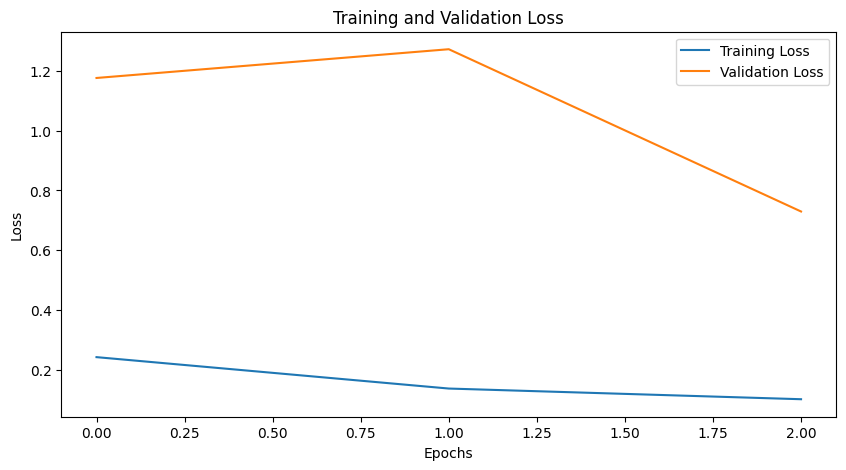

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [9]:
import numpy as np

model_cnn50.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_cnn50(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * np.sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)

print(f'Test Accuracy: {test_acc:.2f}%')

Test Accuracy: 81.57%


ResNet50

In [10]:
# import resnet50 from torchvision
from torchvision.models import resnet50

model_resnet50 = resnet50(pretrained=False, num_classes=2).to(device)

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_resnet50.parameters(), lr=0.001)


train_loss_list = []
val_loss_list = []

for epoch in range(3):  # <--- ไปเปลี่ยนเป็น 10 epochs
    model_resnet50.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model_resnet50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_loss_list.append(epoch_loss)
    
    model_resnet50.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model_resnet50(inputs)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * inputs.size(0)
    
    val_epoch_loss = val_running_loss / len(val_loader.dataset)
    val_loss_list.append(val_epoch_loss)
    
    print(f'Epoch {epoch+1}/{10}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}')

Epoch 1/10, Train Loss: 0.2663, Val Loss: 0.4870
Epoch 2/10, Train Loss: 0.1426, Val Loss: 0.2138
Epoch 3/10, Train Loss: 0.1122, Val Loss: 1.2551


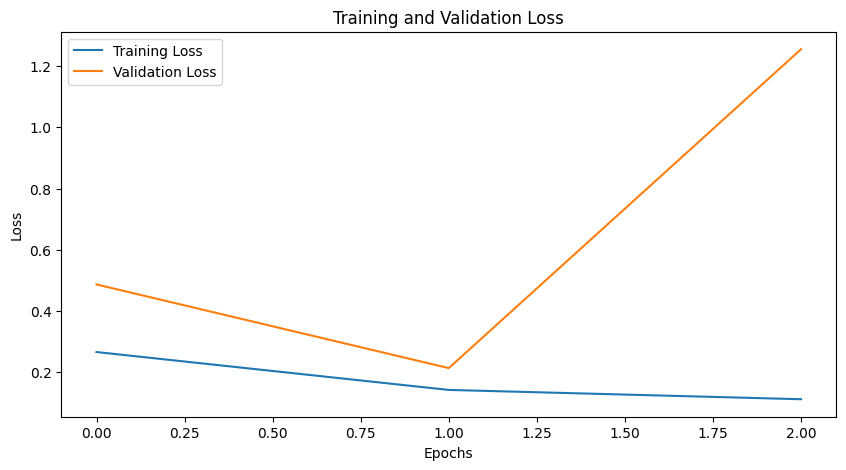

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [13]:
import numpy as np

model_resnet50.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet50(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * np.sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)

print(f'Test Accuracy: {test_acc:.2f}%')

Test Accuracy: 75.32%
